In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys, os, time, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('../parameter_scan'))

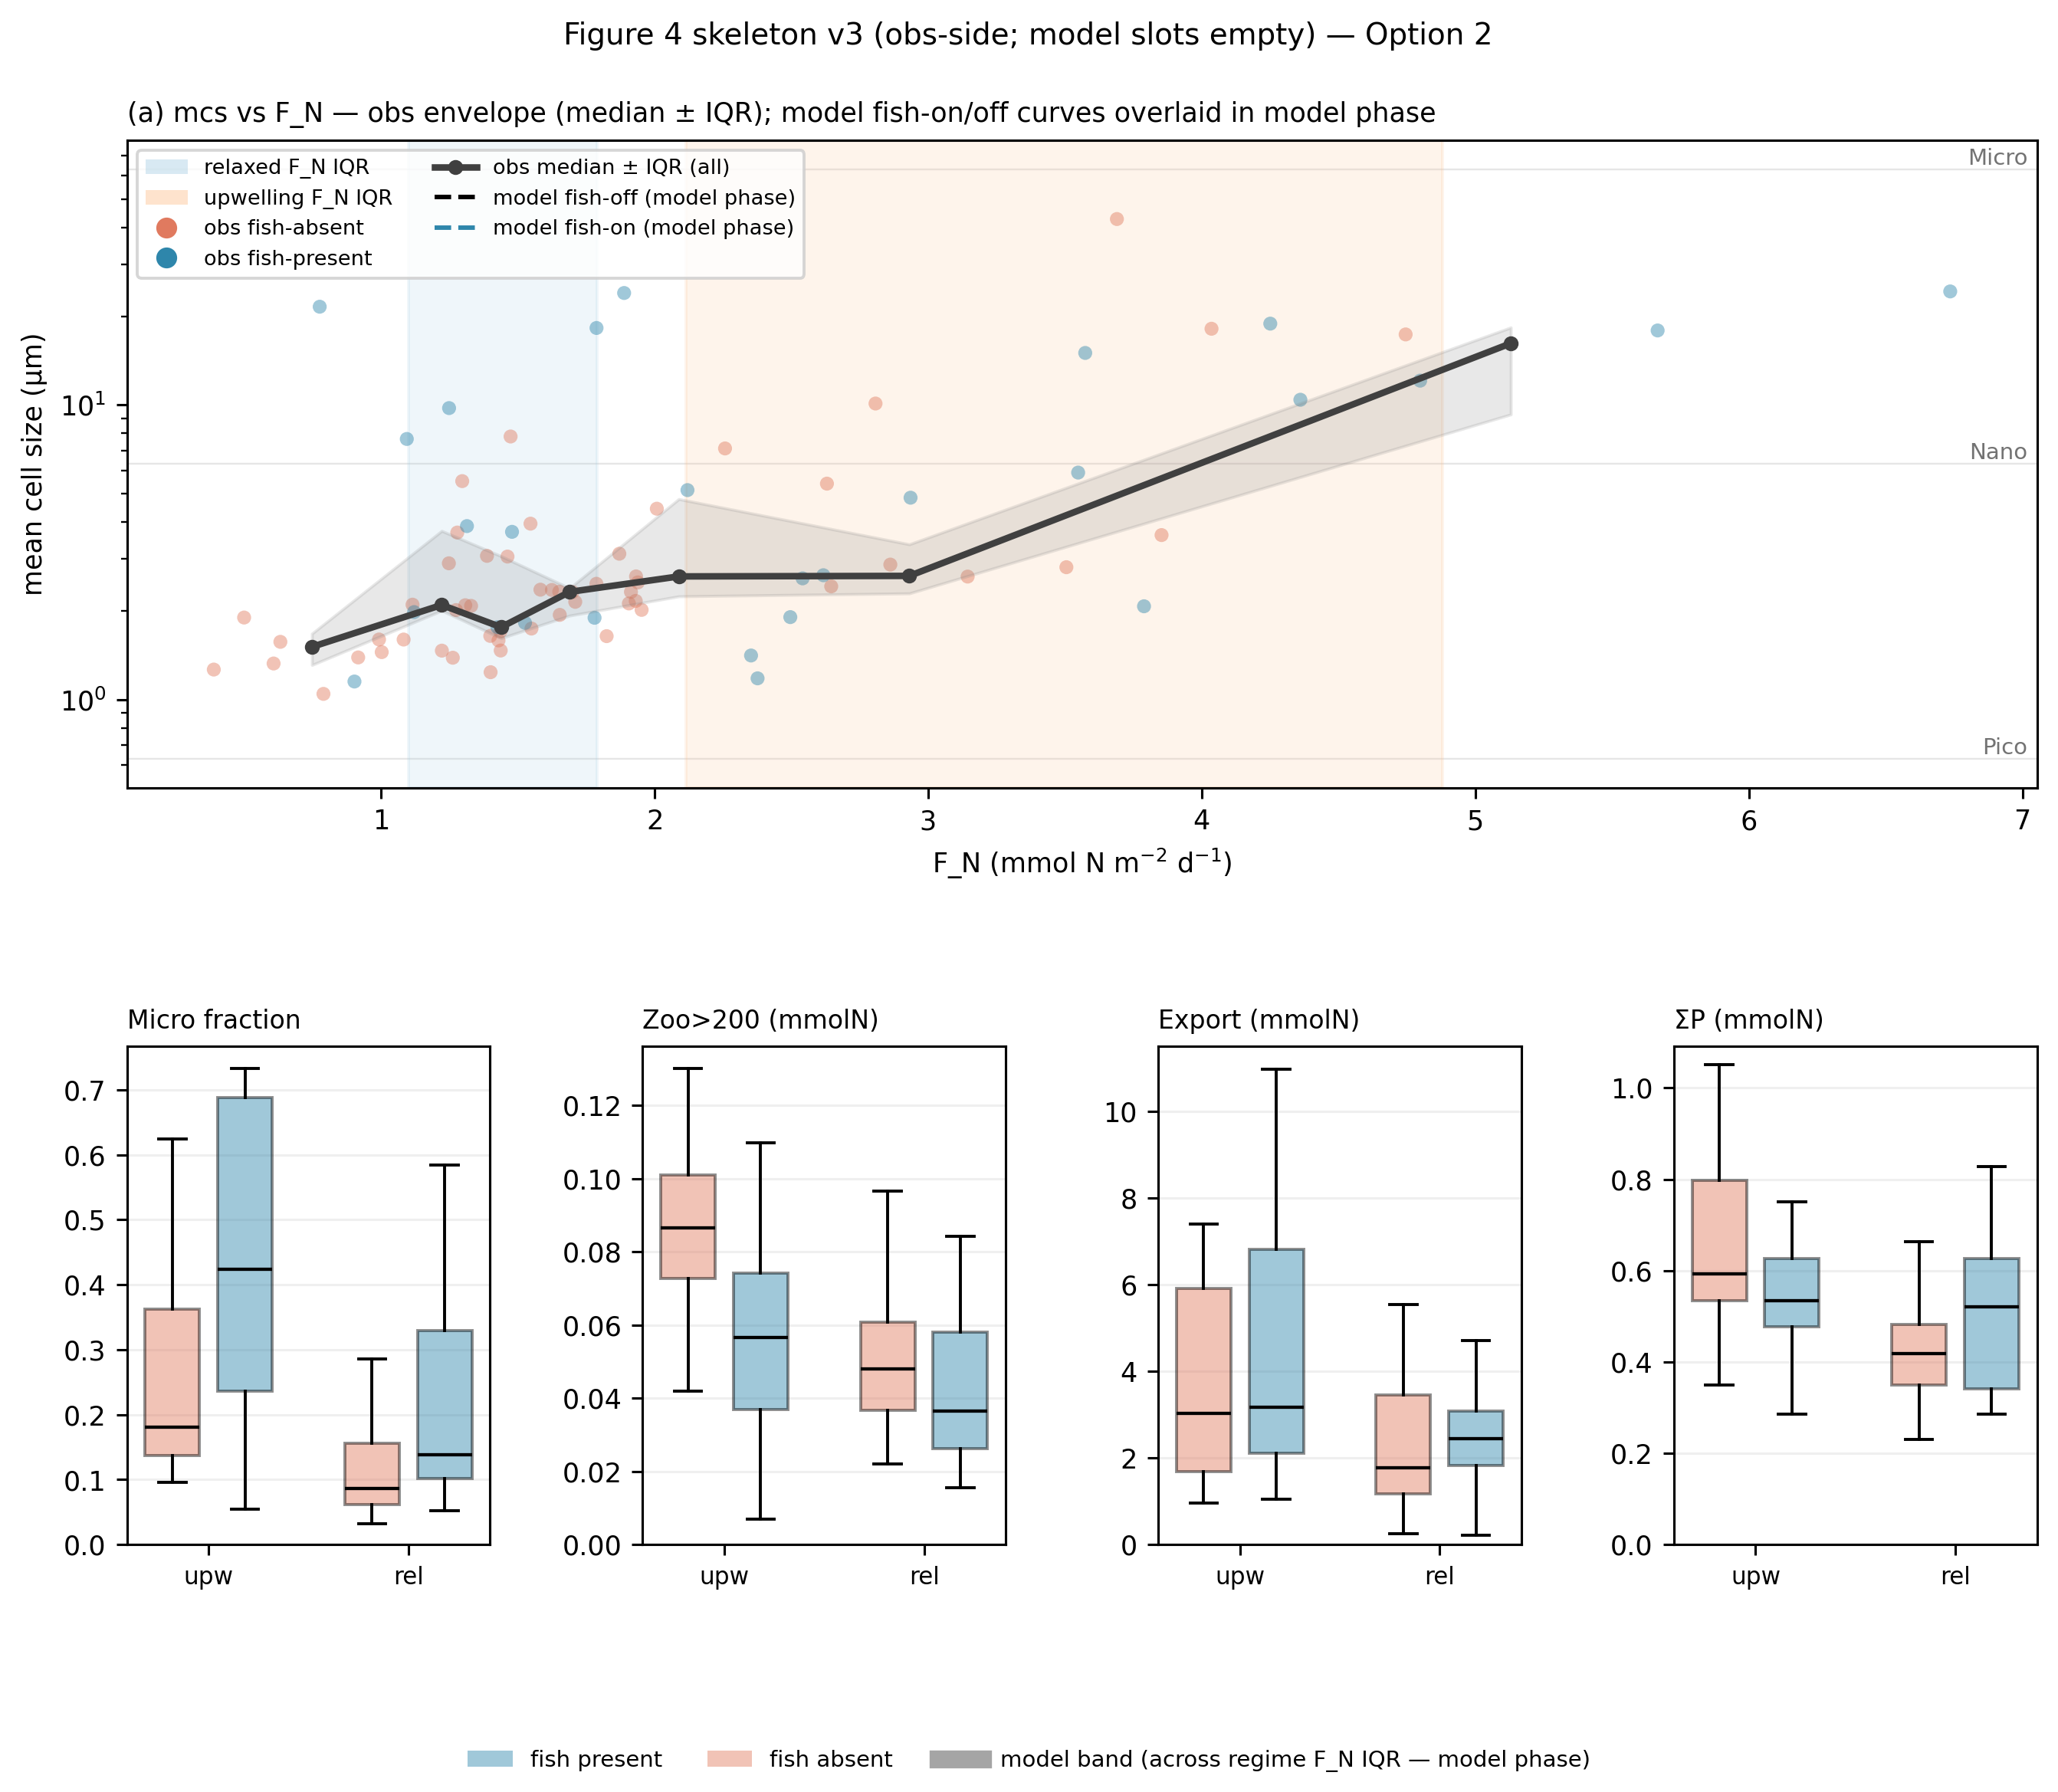

In [8]:
# ============================================================================
# Fig 4 SKELETON v3 (obs-side). Panel (a): single all-obs envelope (binned
# median ± IQR) + faint points by fish; NO per-fish trend lines (their F_N
# ranges barely overlap → leverage artifact; high-F_N fish-absent is unobserved).
# Model fish-on/off curves reserved for the model phase. Panel (b) unchanged.
# ============================================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
try:
    from cariaco_obs import DEFAULT_CSV_PATH as CSV
except Exception:
    CSV = "data/processed/cariaco_monthly_euphotic_dynamic.csv"

PHYTO=["pico_mmolN","nano_mmolN","micro_mmolN"]; LOG_GEO=np.log10([0.63,6.3,63.0]); GEO=np.array([0.63,6.3,63.0])
FN="FN_mmolN_m2_d"; PRE,REC=pd.Timestamp("2005-01-01"),pd.Timestamp("2014-01-01")
COLF={"present":"#2E86AB","absent":"#E07A5F"}

df=pd.read_csv(CSV); df["date"]=pd.to_datetime(df["date"])
Aa=df[PHYTO].to_numpy(float); tot=Aa.sum(1)
with np.errstate(invalid="ignore",divide="ignore"):
    fr=np.where(tot[:,None]>0,Aa/tot[:,None],np.nan)
df["centroid"]=np.where(tot>0,np.nansum(fr*LOG_GEO,1),np.nan); df["mcs"]=10**df["centroid"]
df["micro_frac"]=fr[:,2]; df["phyto_total"]=tot
era=np.where(df.date<PRE,"pre",np.where(df.date>=REC,"recovery","post"))
df["fish"]=np.where(era=="post","absent","present")
df["regime"]=df["regime_adjusted"] if "regime_adjusted" in df.columns else df["upwelling"]
d=df[df["regime"].isin(["upwelling","relaxed"])].copy()
dm=d[d["centroid"].notna() & d[FN].notna()]

plt.rcParams.update({"figure.dpi":140,"font.size":9})
fig=plt.figure(figsize=(10,8.5))
gs=GridSpec(2,4,figure=fig,height_ratios=[1.3,1],top=0.90,bottom=0.13,left=0.08,right=0.97,hspace=0.45,wspace=0.42)

axa=fig.add_subplot(gs[0,:])
for bg in GEO: axa.axhline(bg,color="0.9",lw=0.6,zorder=0)
band_h=[]
for reg,c in [("relaxed","#9ecae1"),("upwelling","#fdbb84")]:
    q=d.loc[d.regime==reg,FN].quantile([.25,.75])
    axa.axvspan(q[.25],q[.75],color=c,alpha=0.16,zorder=0); band_h.append(Patch(facecolor=c,alpha=0.4,label=f"{reg} F_N IQR"))
for fi in ["absent","present"]:
    s=dm[dm.fish==fi]; axa.scatter(s[FN],s["mcs"],s=22,c=COLF[fi],edgecolors="none",alpha=0.45,zorder=2)
bins=np.quantile(dm[FN],np.linspace(0,1,8)); ctr=0.5*(bins[:-1]+bins[1:]); med=[];lo=[];hi=[]
for i in range(len(bins)-1):
    v=dm.loc[(dm[FN]>=bins[i])&(dm[FN]<=bins[i+1]),"mcs"]; med.append(v.median()); lo.append(v.quantile(.25)); hi.append(v.quantile(.75))
axa.fill_between(ctr,lo,hi,color="0.5",alpha=0.18,zorder=3)
axa.plot(ctr,med,color="0.25",lw=2.2,marker="o",ms=4,zorder=4)
axa.set_yscale("log"); axa.set_xlabel("F_N (mmol N m$^{-2}$ d$^{-1}$)"); axa.set_ylabel("mean cell size (µm)")
tr=axa.get_yaxis_transform()
for bg,l in zip(GEO,["Pico","Nano","Micro"]): axa.text(0.995,bg,l,transform=tr,ha="right",va="bottom",fontsize=7.5,color="0.45")
axa.legend(handles=band_h+[
    Line2D([],[],marker='o',ls='',color=COLF['absent'],label='obs fish-absent'),
    Line2D([],[],marker='o',ls='',color=COLF['present'],label='obs fish-present'),
    Line2D([],[],color='0.25',lw=2.2,marker='o',ms=4,label='obs median ± IQR (all)'),
    Line2D([],[],color='k',ls='--',label='model fish-off (model phase)'),
    Line2D([],[],color=COLF['present'],ls='--',label='model fish-on (model phase)')],
    fontsize=7,ncol=2,loc="upper left")
axa.set_title("(a) mcs vs F_N — obs envelope (median ± IQR); model fish-on/off curves overlaid in model phase",loc="left",fontsize=9)

cells=[("upwelling","absent"),("upwelling","present"),("relaxed","absent"),("relaxed","present")]
pos=[1,1.8,3.2,4.0]
metr=[("micro_frac","Micro fraction"),("zoo_gt200_mmolN","Zoo>200 (mmolN)"),
      ("export_flux_corrected_mmolN","Export (mmolN)"),("phyto_total","ΣP (mmolN)")]
for j,(col,lab) in enumerate(metr):
    ax=fig.add_subplot(gs[1,j])
    if col not in d.columns: ax.set_title(f"[missing] {lab}"); ax.axis("off"); continue
    data=[d[(d.regime==r)&(d.fish==f)][col].dropna().values for r,f in cells]
    bp=ax.boxplot(data,positions=pos,widths=0.6,patch_artist=True,showfliers=False,medianprops=dict(color="k",lw=1.1))
    for b,(r,f) in zip(bp["boxes"],cells): b.set_facecolor(COLF[f]); b.set_alpha(0.45)
    ax.set_xticks([1.4,3.6]); ax.set_xticklabels(["upw","rel"],fontsize=8); ax.set_ylim(bottom=0)
    ax.set_title(lab,loc="left",fontsize=8.5); ax.grid(alpha=0.2,axis="y")
fig.legend(handles=[Patch(facecolor=COLF['present'],alpha=0.45,label='fish present'),
                    Patch(facecolor=COLF['absent'],alpha=0.45,label='fish absent'),
                    Line2D([],[],color='0.3',lw=6,alpha=0.5,label='model band (across regime F_N IQR — model phase)')],
           fontsize=7.5,loc="lower center",ncol=3,frameon=False)
fig.suptitle("Figure 4 skeleton v3 (obs-side; model slots empty) — Option 2",fontsize=10,y=0.965)
plt.show()

In [2]:
# ============================================================================
# Fig 4 — Step 1: mcs-vs-F_N era separation in the overlap window (SWEEP TABLE)
# Quantifies the size level-shift on the F_N axis, restricted to the F_N range
# the eras share. Sweeps every "check both" toggle:
#   scope    : pooled (all regimes) | within-upwelling
#   metric   : raw centroid | deseasonalised (monthly climatology removed)
#   window   : strict (full F_N intersection) | trimmed (5-95 pct intersection)
#   grouping : pre vs post | (pre+recovery) vs post
# Per combo: n/group, F_N window, F_N-controlled level-shift (OLS centroid ~
# F_N + is_high; coef in centroid units + 10^coef fold in µm), 95% CI & p, the
# F_N*era interaction p (clean-level-shift check vs the full-range p=0.002), and
# a non-parametric median cross-check (one-sided Mann-Whitney, high>low). No model.
# ============================================================================
import numpy as np, pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import mannwhitneyu

try:
    from cariaco_obs import DEFAULT_CSV_PATH as CSV
except Exception:
    CSV = "data/processed/cariaco_monthly_euphotic_dynamic.csv"  # adjust to your path

PHYTO  = ["pico_mmolN", "nano_mmolN", "micro_mmolN"]
LOG_GEO = np.log10([0.63, 6.3, 63.0])          # Sieburth bin geomeans (µm)
FN = "FN_mmolN_m2_d"
PRE_CUT, REC_CUT = pd.Timestamp("2005-01-01"), pd.Timestamp("2014-01-01")

# ---- load + per-month centroid (= R size_centroid) -------------------------
df = pd.read_csv(CSV); df["date"] = pd.to_datetime(df["date"])
P = df[PHYTO].to_numpy(float); tot = P.sum(1)
with np.errstate(invalid="ignore", divide="ignore"):
    fr = np.where(tot[:, None] > 0, P / tot[:, None], np.nan)
df["centroid"] = np.where(tot > 0, np.nansum(fr * LOG_GEO, 1), np.nan)
# deseasonalised: subtract monthly climatology, re-centre on overall mean (Fig 3 procedure)
df["centroid_ds"] = (df["centroid"]
                     - df.groupby(df["date"].dt.month)["centroid"].transform("mean")
                     + df["centroid"].mean())
df["era"] = np.where(df["date"] < PRE_CUT, "pre",
            np.where(df["date"] >= REC_CUT, "recovery", "post"))
df["regime"] = df["regime_adjusted"] if "regime_adjusted" in df.columns else df["upwelling"]

d = df[df["centroid"].notna() & df[FN].notna()].copy()   # HPLC months w/ valid F_N

def overlap(a, b, q):
    return max(a.quantile(q), b.quantile(q)), min(a.quantile(1 - q), b.quantile(1 - q))

def one(scope, metric, window, grouping):
    sub  = d if scope == "pooled" else d[d["regime"] == "upwelling"]
    high = ["pre", "recovery"] if grouping == "prerec_vs_post" else ["pre"]
    g = sub[sub["era"].isin(high + ["post"])].copy()
    g["is_high"] = g["era"].isin(high).astype(int)
    q = 0.0 if window == "strict" else 0.05
    lo, hi = overlap(g.loc[g.is_high == 1, FN], g.loc[g.is_high == 0, FN], q)
    w = g[(g[FN] >= lo) & (g[FN] <= hi)]
    y = "centroid" if metric == "raw" else "centroid_ds"
    nh, nl = int((w.is_high == 1).sum()), int((w.is_high == 0).sum())
    r = dict(scope=scope, metric=metric, window=window, grouping=grouping,
             n_hi=nh, n_lo=nl, FN_lo=round(lo, 2), FN_hi=round(hi, 2))
    if nh >= 3 and nl >= 3:
        m  = smf.ols(f"{y} ~ {FN} + is_high", data=w).fit()
        mi = smf.ols(f"{y} ~ {FN} * is_high", data=w).fit()
        coef, ci = m.params["is_high"], m.conf_int().loc["is_high"]
        hv, lv = w.loc[w.is_high == 1, y], w.loc[w.is_high == 0, y]
        try: pmw = mannwhitneyu(hv, lv, alternative="greater").pvalue
        except ValueError: pmw = np.nan
        r.update(dshift=round(coef, 3), fold_um=round(10 ** coef, 2),
                 ci=f"[{ci[0]:+.2f},{ci[1]:+.2f}]", p_shift=round(m.pvalues["is_high"], 4),
                 p_inter=round(mi.pvalues[f"{FN}:is_high"], 4),
                 med_hi=round(hv.median(), 3), med_lo=round(lv.median(), 3),
                 p_mwu=round(pmw, 4))
    else:
        r.update(dshift=np.nan, fold_um=np.nan, ci="-", p_shift=np.nan,
                 p_inter=np.nan, med_hi=np.nan, med_lo=np.nan, p_mwu=np.nan)
    return r

tab = pd.DataFrame([one(s, m, w, gr)
                    for s  in ("pooled", "within-upwelling")
                    for m  in ("raw", "deseason")
                    for w  in ("strict", "trimmed")
                    for gr in ("pre_vs_post", "prerec_vs_post")])
pd.set_option("display.width", 220, "display.max_columns", 50)
print(f"HPLC+F_N months: {len(d)} | regimes: {dict(d['regime'].value_counts())}")
print(f"era n: {dict(d['era'].value_counts())}\n")
print(tab.to_string(index=False))

HPLC+F_N months: 88 | regimes: {'relaxed': np.int64(54), 'upwelling': np.int64(28), 'transition': np.int64(6)}
era n: {'post': np.int64(57), 'pre': np.int64(17), 'recovery': np.int64(14)}

           scope   metric  window       grouping  n_hi  n_lo  FN_lo  FN_hi  dshift  fold_um            ci  p_shift  p_inter  med_hi  med_lo  p_mwu
          pooled      raw  strict    pre_vs_post    13    53   0.65   4.92   0.106     1.28 [-0.06,+0.27]   0.2033   0.1838   0.685   0.372 0.0589
          pooled      raw  strict prerec_vs_post    27    53   0.65   4.92   0.100     1.26 [-0.05,+0.25]   0.1929   0.0072   0.569   0.372 0.0701
          pooled      raw trimmed    pre_vs_post    11    46   1.01   3.89   0.107     1.28 [-0.08,+0.29]   0.2518   0.4683   0.685   0.372 0.1184
          pooled      raw trimmed prerec_vs_post    22    49   0.84   3.89   0.074     1.19 [-0.08,+0.23]   0.3400   0.0710   0.416   0.366 0.2412
          pooled deseason  strict    pre_vs_post    13    53   0.65   4.92  

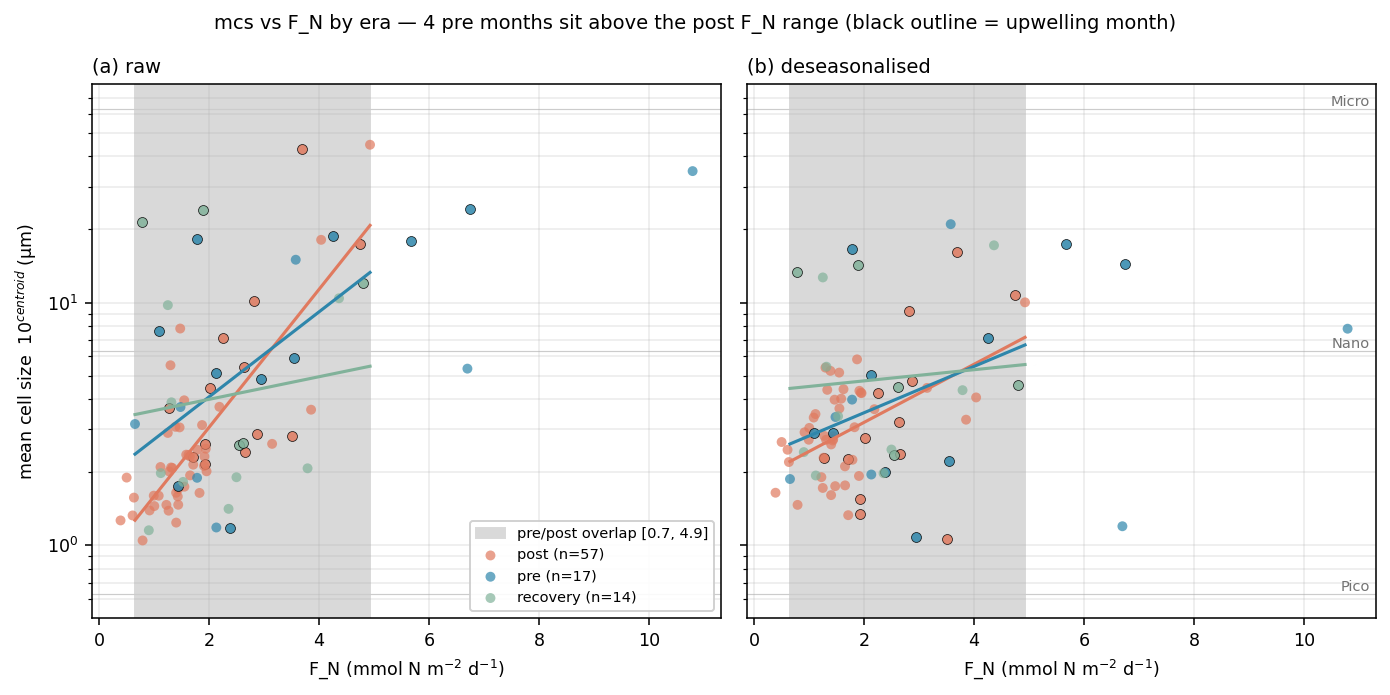

In [3]:
# ============================================================================
# Fig 4 — Step 1 (visual): mcs vs F_N by era, raw | deseasonalised
# Shows the out-of-overlap pre bloom months + the seasonal collapse.
# Self-contained (reloads + recomputes; matches the sweep-table cell).
# ============================================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

try:
    from cariaco_obs import DEFAULT_CSV_PATH as CSV
except Exception:
    CSV = "data/processed/cariaco_monthly_euphotic_dynamic.csv"  # adjust to your path

PHYTO = ["pico_mmolN", "nano_mmolN", "micro_mmolN"]
GEO = np.array([0.63, 6.3, 63.0]); LOG_GEO = np.log10(GEO)
FN = "FN_mmolN_m2_d"
PRE_CUT, REC_CUT = pd.Timestamp("2005-01-01"), pd.Timestamp("2014-01-01")
ERA_C = {"pre": "#2E86AB", "post": "#E07A5F", "recovery": "#81B29A"}  # handover palette

df = pd.read_csv(CSV); df["date"] = pd.to_datetime(df["date"])
P = df[PHYTO].to_numpy(float); tot = P.sum(1)
with np.errstate(invalid="ignore", divide="ignore"):
    fr = np.where(tot[:, None] > 0, P / tot[:, None], np.nan)
df["centroid"] = np.where(tot > 0, np.nansum(fr * LOG_GEO, 1), np.nan)
df["centroid_ds"] = (df["centroid"]
                     - df.groupby(df["date"].dt.month)["centroid"].transform("mean")
                     + df["centroid"].mean())
df["era"] = np.where(df["date"] < PRE_CUT, "pre",
            np.where(df["date"] >= REC_CUT, "recovery", "post"))
df["regime"] = df["regime_adjusted"] if "regime_adjusted" in df.columns else df["upwelling"]
d = df[df["centroid"].notna() & df[FN].notna()].copy()

fp, fq = d.loc[d.era == "pre", FN], d.loc[d.era == "post", FN]
LO, HI = max(fp.min(), fq.min()), min(fp.max(), fq.max())   # pre/post strict overlap
n_pre_above = int((fp > HI).sum())

plt.rcParams.update({"figure.dpi": 140, "font.size": 9})
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
for ax, (ycol, title) in zip(axes, [("centroid", "(a) raw"),
                                     ("centroid_ds", "(b) deseasonalised")]):
    ax.axvspan(LO, HI, color="0.85", zorder=0, label=f"pre/post overlap [{LO:.1f}, {HI:.1f}]")
    for bg in GEO:
        ax.axhline(bg, color="0.8", lw=0.6, zorder=0)
    for era in ["post", "pre", "recovery"]:
        s = d[d.era == era]; up = s.regime == "upwelling"
        ax.scatter(s.loc[up, FN], 10**s.loc[up, ycol], s=26, c=ERA_C[era],
                   edgecolors="k", linewidths=0.4, alpha=0.85, zorder=3)
        ax.scatter(s.loc[~up, FN], 10**s.loc[~up, ycol], s=26, c=ERA_C[era],
                   edgecolors="none", alpha=0.7, zorder=3, label=f"{era} (n={len(s)})")
        w = s[(s[FN] >= LO) & (s[FN] <= HI)]
        if len(w) >= 3:
            b = np.polyfit(w[FN], w[ycol], 1); xx = np.linspace(LO, HI, 20)
            ax.plot(xx, 10**(b[0]*xx + b[1]), color=ERA_C[era], lw=1.6, zorder=4)
    ax.set_yscale("log")
    ax.set_xlabel("F_N (mmol N m$^{-2}$ d$^{-1}$)")
    ax.set_title(title, loc="left", fontsize=10)
    ax.grid(alpha=0.25, which="both")
axes[0].set_ylabel("mean cell size  10$^{centroid}$ (µm)")
trans = axes[1].get_yaxis_transform()
for bg, lab in zip(GEO, ["Pico", "Nano", "Micro"]):
    axes[1].text(0.99, bg, lab, transform=trans, ha="right", va="bottom",
                 fontsize=7.5, color="0.45")
axes[0].legend(fontsize=7.5, loc="lower right", framealpha=0.9)
fig.suptitle(f"mcs vs F_N by era — {n_pre_above} pre months sit above the post F_N range "
             f"(black outline = upwelling month)", fontsize=10)
fig.tight_layout(); plt.show()

regime x fish cross-tab (n):
fish        absent  present
regime                     
relaxed         42       12
transition       2        4
upwelling       13       15 

mcs present(pre+rec) vs absent(post):
  all          present med=4.84µm (n=31) | absent med=2.32µm (n=57) | fold=2.09x | MWU(>)=0.0072
  upwelling    present med=7.66µm (n=15) | absent med=3.69µm (n=13) | fold=2.08x | MWU(>)=0.1068
  relaxed      present med=2.03µm (n=12) | absent med=2.05µm (n=42) | fold=0.99x | MWU(>)=0.1719


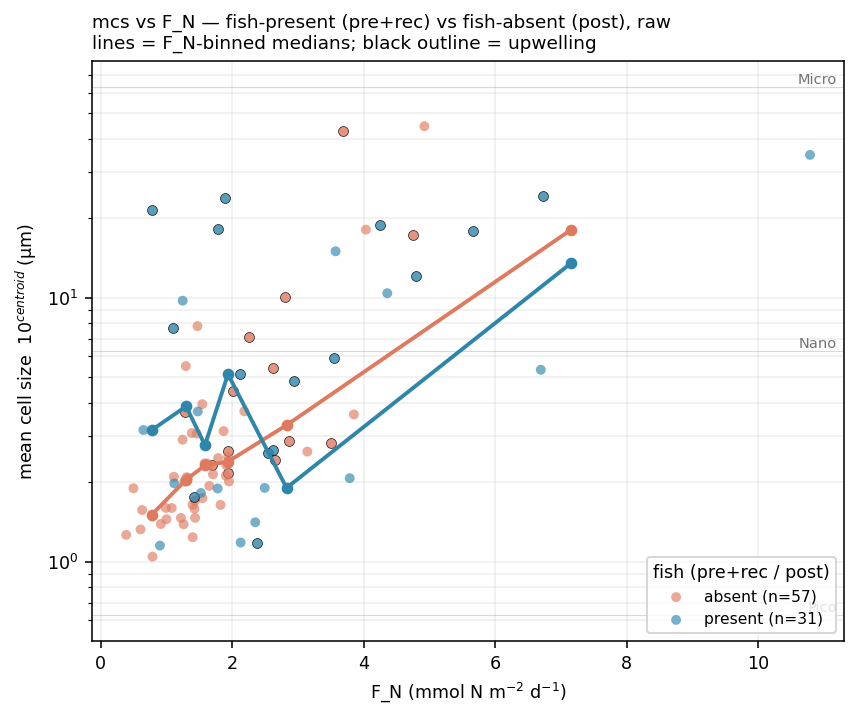

In [4]:
# ============================================================================
# Fig 4 — Step 1 redo: mcs vs F_N, fish-present (pre+rec) vs fish-absent (post),
# RAW, full range. + regime x fish cross-tab + categorical contrast preview
# (a numeric peek at what the 2x2 boxplot would formalize).
# ============================================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

try:
    from cariaco_obs import DEFAULT_CSV_PATH as CSV
except Exception:
    CSV = "data/processed/cariaco_monthly_euphotic_dynamic.csv"

PHYTO = ["pico_mmolN", "nano_mmolN", "micro_mmolN"]
GEO = np.array([0.63, 6.3, 63.0]); LOG_GEO = np.log10(GEO)
FN = "FN_mmolN_m2_d"
PRE_CUT, REC_CUT = pd.Timestamp("2005-01-01"), pd.Timestamp("2014-01-01")
COL = {"present": "#2E86AB", "absent": "#E07A5F"}

df = pd.read_csv(CSV); df["date"] = pd.to_datetime(df["date"])
P = df[PHYTO].to_numpy(float); tot = P.sum(1)
with np.errstate(invalid="ignore", divide="ignore"):
    fr = np.where(tot[:, None] > 0, P / tot[:, None], np.nan)
df["centroid"] = np.where(tot > 0, np.nansum(fr * LOG_GEO, 1), np.nan)
era = np.where(df["date"] < PRE_CUT, "pre",
       np.where(df["date"] >= REC_CUT, "recovery", "post"))
df["fish"] = np.where(era == "post", "absent", "present")   # pre+recovery = present
df["regime"] = df["regime_adjusted"] if "regime_adjusted" in df.columns else df["upwelling"]
df["mcs"] = 10 ** df["centroid"]
d = df[df["centroid"].notna() & df[FN].notna()].copy()

print("regime x fish cross-tab (n):")
print(pd.crosstab(d["regime"], d["fish"]), "\n")
def contrast(sub, label):
    pres = sub.loc[sub.fish == "present", "mcs"]; abse = sub.loc[sub.fish == "absent", "mcs"]
    if len(pres) >= 3 and len(abse) >= 3:
        p = mannwhitneyu(pres, abse, alternative="greater").pvalue
        print(f"  {label:12s} present med={pres.median():.2f}µm (n={len(pres):2d}) | "
              f"absent med={abse.median():.2f}µm (n={len(abse):2d}) | "
              f"fold={pres.median()/abse.median():.2f}x | MWU(>)={p:.4f}")
    else:
        print(f"  {label:12s} too thin (present n={len(pres)}, absent n={len(abse)})")
print("mcs present(pre+rec) vs absent(post):")
for lab, sub in [("all", d), ("upwelling", d[d.regime=="upwelling"]), ("relaxed", d[d.regime=="relaxed"])]:
    contrast(sub, lab)

plt.rcParams.update({"figure.dpi": 140, "font.size": 9})
fig, ax = plt.subplots(figsize=(6.2, 5.2))
for bg in GEO: ax.axhline(bg, color="0.85", lw=0.6, zorder=0)
bins = np.quantile(d[FN], np.linspace(0, 1, 7)); ctr = 0.5*(bins[:-1]+bins[1:])
for grp in ["absent", "present"]:
    s = d[d.fish == grp]; up = s.regime == "upwelling"
    ax.scatter(s.loc[up, FN], s.loc[up, "mcs"], s=26, c=COL[grp],
               edgecolors="k", linewidths=0.4, alpha=0.8, zorder=3)
    ax.scatter(s.loc[~up, FN], s.loc[~up, "mcs"], s=26, c=COL[grp],
               edgecolors="none", alpha=0.65, zorder=3, label=f"{grp} (n={len(s)})")
    med = [s.loc[(s[FN]>=bins[i]) & (s[FN]<=bins[i+1]), "mcs"].median() for i in range(len(bins)-1)]
    ax.plot(ctr, med, color=COL[grp], lw=2.0, marker="o", ms=5, zorder=5)
ax.set_yscale("log")
ax.set_xlabel("F_N (mmol N m$^{-2}$ d$^{-1}$)"); ax.set_ylabel("mean cell size  10$^{centroid}$ (µm)")
trans = ax.get_yaxis_transform()
for bg, lab in zip(GEO, ["Pico","Nano","Micro"]):
    ax.text(0.99, bg, lab, transform=trans, ha="right", va="bottom", fontsize=7.5, color="0.45")
ax.legend(fontsize=8, loc="lower right", title="fish (pre+rec / post)")
ax.set_title("mcs vs F_N — fish-present (pre+rec) vs fish-absent (post), raw\n"
             "lines = F_N-binned medians; black outline = upwelling", loc="left", fontsize=9.5)
ax.grid(alpha=0.2, which="both"); fig.tight_layout(); plt.show()

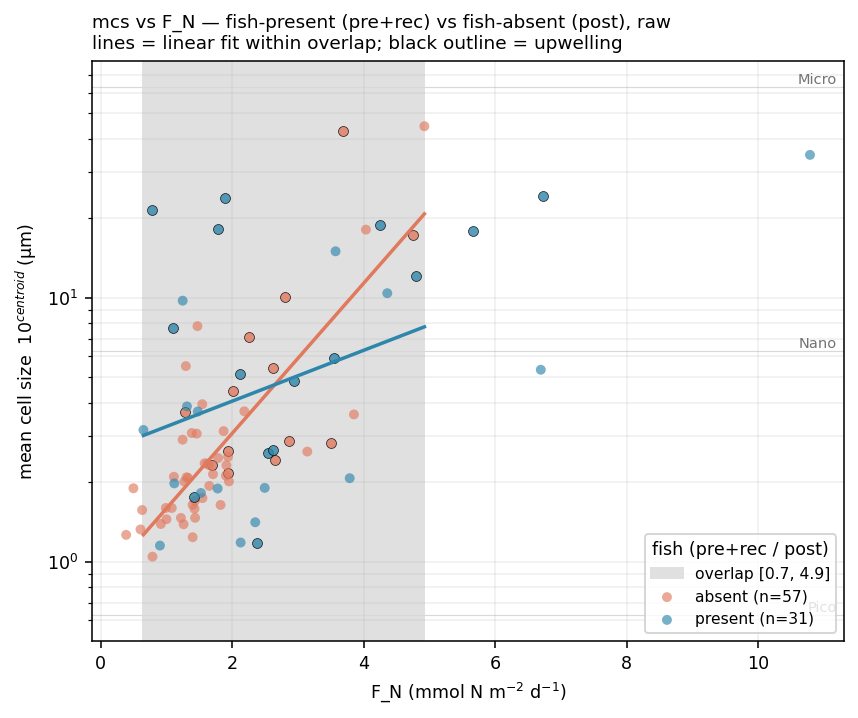

In [5]:
# Fig 4 — Step 1: mcs vs F_N, fish-present (pre+rec) vs fish-absent (post), RAW.
# Same linear fit as the first plot (within the present/absent overlap window).
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
try:
    from cariaco_obs import DEFAULT_CSV_PATH as CSV
except Exception:
    CSV = "data/processed/cariaco_monthly_euphotic_dynamic.csv"

PHYTO = ["pico_mmolN","nano_mmolN","micro_mmolN"]
GEO = np.array([0.63,6.3,63.0]); LOG_GEO = np.log10(GEO)
FN = "FN_mmolN_m2_d"
PRE_CUT, REC_CUT = pd.Timestamp("2005-01-01"), pd.Timestamp("2014-01-01")
COL = {"present":"#2E86AB","absent":"#E07A5F"}

df = pd.read_csv(CSV); df["date"] = pd.to_datetime(df["date"])
P = df[PHYTO].to_numpy(float); tot = P.sum(1)
with np.errstate(invalid="ignore", divide="ignore"):
    fr = np.where(tot[:,None]>0, P/tot[:,None], np.nan)
df["centroid"] = np.where(tot>0, np.nansum(fr*LOG_GEO,1), np.nan)
era = np.where(df["date"]<PRE_CUT,"pre", np.where(df["date"]>=REC_CUT,"recovery","post"))
df["fish"] = np.where(era=="post","absent","present")        # pre+recovery = present
df["regime"] = df["regime_adjusted"] if "regime_adjusted" in df.columns else df["upwelling"]
d = df[df["centroid"].notna() & df[FN].notna()].copy()

fp, fa = d.loc[d.fish=="present",FN], d.loc[d.fish=="absent",FN]
LO, HI = max(fp.min(),fa.min()), min(fp.max(),fa.max())

plt.rcParams.update({"figure.dpi":140,"font.size":9})
fig, ax = plt.subplots(figsize=(6.2,5.2))
ax.axvspan(LO,HI,color="0.88",zorder=0,label=f"overlap [{LO:.1f}, {HI:.1f}]")
for bg in GEO: ax.axhline(bg,color="0.85",lw=0.6,zorder=0)
for grp in ["absent","present"]:
    s = d[d.fish==grp]; up = s.regime=="upwelling"
    ax.scatter(s.loc[up,FN], 10**s.loc[up,"centroid"], s=26, c=COL[grp],
               edgecolors="k", linewidths=0.4, alpha=0.8, zorder=3)
    ax.scatter(s.loc[~up,FN], 10**s.loc[~up,"centroid"], s=26, c=COL[grp],
               edgecolors="none", alpha=0.65, zorder=3, label=f"{grp} (n={len(s)})")
    w = s[(s[FN]>=LO)&(s[FN]<=HI)]
    if len(w)>=3:
        b = np.polyfit(w[FN], w["centroid"], 1); xx = np.linspace(LO,HI,20)
        ax.plot(xx, 10**(b[0]*xx+b[1]), color=COL[grp], lw=1.8, zorder=5)
ax.set_yscale("log")
ax.set_xlabel("F_N (mmol N m$^{-2}$ d$^{-1}$)"); ax.set_ylabel("mean cell size  10$^{centroid}$ (µm)")
trans = ax.get_yaxis_transform()
for bg,lab in zip(GEO,["Pico","Nano","Micro"]):
    ax.text(0.99,bg,lab,transform=trans,ha="right",va="bottom",fontsize=7.5,color="0.45")
ax.legend(fontsize=8, loc="lower right", title="fish (pre+rec / post)")
ax.set_title("mcs vs F_N — fish-present (pre+rec) vs fish-absent (post), raw\n"
             "lines = linear fit within overlap; black outline = upwelling", loc="left", fontsize=9.5)
ax.grid(alpha=0.2, which="both"); fig.tight_layout(); plt.show()

REGIME_SRC = regime_adjusted   (n total = 82)
cell summary [regime x fish]:  n | F_N med[IQR] | mcs med[IQR] µm
  upwelling absent  n=13 | F_N 2.63[1.93,2.86] | mcs 3.69[2.62,7.11]
  upwelling present n=15 | F_N 2.54[1.84,3.90] | mcs 7.66[3.74,18.56]
  relaxed   absent  n=42 | F_N 1.43[1.23,1.70] | mcs 2.05[1.59,2.49]
  relaxed   present n=12 | F_N 1.65[1.30,2.77] | mcs 2.03[1.88,5.35]

fish effect (present vs absent) per regime:
  upwelling raw fold=2.08x (MWU p=0.107) | F_N-controlled fold=1.36x (p=0.373, n=28)
  relaxed   raw fold=0.99x (MWU p=0.172) | F_N-controlled fold=1.12x (p=0.536, n=54)

conditional test (regime x fish interaction on centroid, F_N-controlled):
  C(regime)[T.upwelling]:is_present: coef=+0.062 p=0.669


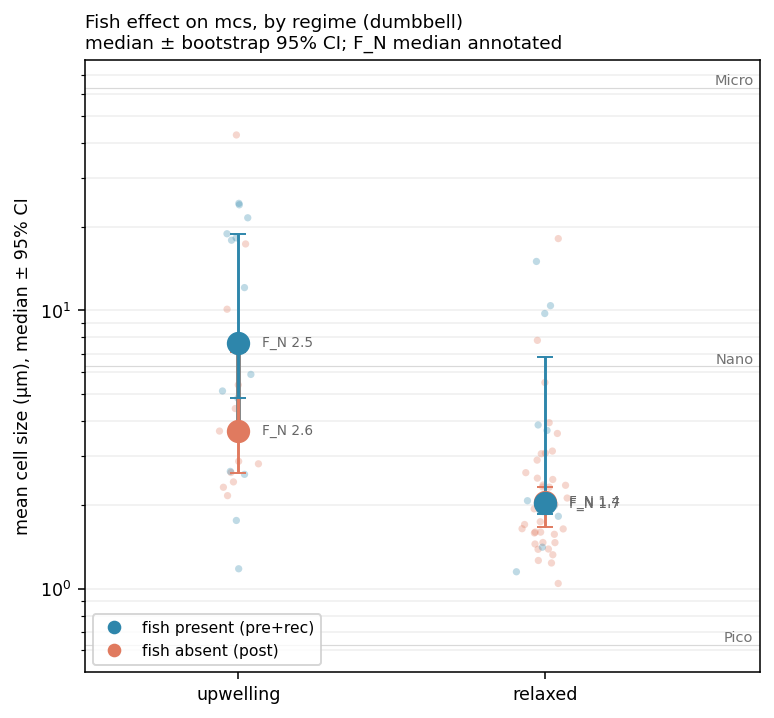

In [10]:
# ============================================================================
# Fig 4 — Step 1: dumbbell view + diagnostic print.
# Dumbbell = median mcs absent->present per regime (bootstrap 95% CI), F_N
# median annotated. Diagnostic: per-cell n/F_N/mcs, raw + F_N-controlled fish
# effect per regime, and the regime x fish interaction (the conditional test).
# ============================================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import mannwhitneyu
from matplotlib.lines import Line2D
np.random.seed(0)
try:
    from cariaco_obs import DEFAULT_CSV_PATH as CSV
except Exception:
    CSV = "data/processed/cariaco_monthly_euphotic_dynamic.csv"

PHYTO = ["pico_mmolN","nano_mmolN","micro_mmolN"]
GEO = np.array([0.63,6.3,63.0]); LOG_GEO = np.log10(GEO)
FN = "FN_mmolN_m2_d"
PRE_CUT, REC_CUT = pd.Timestamp("2005-01-01"), pd.Timestamp("2014-01-01")
COL = {"present":"#2E86AB","absent":"#E07A5F"}
REGIME_SRC = "regime_adjusted"   # cleaner; "upwelling" = raw sharp 22C (keeps transition months)

df = pd.read_csv(CSV); df["date"] = pd.to_datetime(df["date"])
P = df[PHYTO].to_numpy(float); tot = P.sum(1)
with np.errstate(invalid="ignore", divide="ignore"):
    fr = np.where(tot[:,None]>0, P/tot[:,None], np.nan)
df["centroid"] = np.where(tot>0, np.nansum(fr*LOG_GEO,1), np.nan)
df["mcs"] = 10**df["centroid"]
era = np.where(df["date"]<PRE_CUT,"pre", np.where(df["date"]>=REC_CUT,"recovery","post"))
df["fish"] = np.where(era=="post","absent","present")
df["regime"] = df[REGIME_SRC] if REGIME_SRC in df.columns else df["upwelling"]
df["is_present"] = (df["fish"]=="present").astype(int)
d = df[df["centroid"].notna() & df[FN].notna() & df["regime"].isin(["upwelling","relaxed"])].copy()

def med_ci(v, n=2000):
    v = np.asarray(v)
    if len(v)<2: return (np.median(v) if len(v) else np.nan), np.nan, np.nan
    bs = [np.median(np.random.choice(v, len(v), replace=True)) for _ in range(n)]
    return np.median(v), np.percentile(bs,2.5), np.percentile(bs,97.5)

# ---------- diagnostic print ----------
print(f"REGIME_SRC = {REGIME_SRC}   (n total = {len(d)})")
print("cell summary [regime x fish]:  n | F_N med[IQR] | mcs med[IQR] µm")
for reg in ["upwelling","relaxed"]:
    for fi in ["absent","present"]:
        s = d[(d.regime==reg)&(d.fish==fi)]
        fq = s[FN].quantile([.25,.5,.75]); mq = s["mcs"].quantile([.25,.5,.75])
        print(f"  {reg:9s} {fi:7s} n={len(s):2d} | "
              f"F_N {fq[.5]:4.2f}[{fq[.25]:.2f},{fq[.75]:.2f}] | "
              f"mcs {mq[.5]:4.2f}[{mq[.25]:.2f},{mq[.75]:.2f}]")
print("\nfish effect (present vs absent) per regime:")
for reg in ["upwelling","relaxed"]:
    s = d[d.regime==reg]; pres, abse = s[s.fish=='present']['mcs'], s[s.fish=='absent']['mcs']
    pmw = mannwhitneyu(pres, abse, alternative='greater').pvalue if min(len(pres),len(abse))>=3 else np.nan
    m = smf.ols(f"centroid ~ {FN} + is_present", data=s).fit()
    print(f"  {reg:9s} raw fold={pres.median()/abse.median():.2f}x (MWU p={pmw:.3f}) | "
          f"F_N-controlled fold={10**m.params['is_present']:.2f}x (p={m.pvalues['is_present']:.3f}, n={len(s)})")
mi = smf.ols(f"centroid ~ {FN} + C(regime)*is_present", data=d).fit()
print("\nconditional test (regime x fish interaction on centroid, F_N-controlled):")
for k in [k for k in mi.pvalues.index if ":" in k]:
    print(f"  {k}: coef={mi.params[k]:+.3f} p={mi.pvalues[k]:.3f}")

# ---------- dumbbell viz ----------
plt.rcParams.update({"figure.dpi":140,"font.size":9})
fig, ax = plt.subplots(figsize=(5.6,5.2))
for bg in GEO: ax.axhline(bg,color="0.85",lw=0.6,zorder=0)
for i,reg in enumerate(["upwelling","relaxed"]):
    x = i+1; st = {}
    for fi in ["absent","present"]:
        v = d[(d.regime==reg)&(d.fish==fi)]["mcs"].values
        st[fi] = med_ci(v)
        ax.scatter(np.random.normal(x,0.03,len(v)), v, s=14, c=COL[fi],
                   edgecolors="none", alpha=0.30, zorder=2)
    ax.plot([x,x],[st['absent'][0],st['present'][0]], color="0.5", lw=2.5, zorder=3)
    for fi in ["absent","present"]:
        m,lo,hi = st[fi]
        ax.errorbar(x, m, yerr=[[m-lo],[hi-m]], fmt='o', ms=11, color=COL[fi],
                    ecolor=COL[fi], elinewidth=1.5, capsize=4, zorder=4)
        fnmed = np.median(d[(d.regime==reg)&(d.fish==fi)][FN])
        ax.annotate(f"F_N {fnmed:.1f}", (x,m), xytext=(12,0), textcoords="offset points",
                    fontsize=7, color="0.4", va="center")
ax.set_yscale("log"); ax.set_xticks([1,2]); ax.set_xticklabels(["upwelling","relaxed"])
ax.set_xlim(0.5,2.7); ax.set_ylabel("mean cell size (µm), median ± 95% CI")
trans = ax.get_yaxis_transform()
for bg,lab in zip(GEO,["Pico","Nano","Micro"]):
    ax.text(0.99,bg,lab,transform=trans,ha="right",va="bottom",fontsize=7.5,color="0.45")
ax.legend(handles=[Line2D([],[],marker='o',ls='',color=COL['present'],label='fish present (pre+rec)'),
                   Line2D([],[],marker='o',ls='',color=COL['absent'],label='fish absent (post)')],
          fontsize=8, loc="lower left")
ax.set_title("Fish effect on mcs, by regime (dumbbell)\nmedian ± bootstrap 95% CI; F_N median annotated",
             loc="left", fontsize=9.5)
ax.grid(alpha=0.2, axis="y", which="both"); fig.tight_layout(); plt.show()

=== era level-shift  ANCOVA  centroid ~ temp + era  (fold = 10^coef) ===
  temp_50m  pre_post      fold=1.52x  p_shift=0.087  p_inter=0.843  n=81
  temp_50m  prerec_post   fold=1.42x  p_shift=0.067  p_inter=0.572  n=95
  Temp_C    pre_post      fold=1.56x  p_shift=0.074  p_inter=0.908  n=80
  Temp_C    prerec_post   fold=1.35x  p_shift=0.127  p_inter=0.298  n=94

=== where it lives: within-regime raw mcs contrast (median fold, MWU>) ===
  upwelling(<=22)  pre/post     fold=2.07x (n=10/16, MWU p=0.081)
  upwelling(<=22)  prerec/post  fold=2.34x (n=15/16, MWU p=0.050)
  relaxed(>22)     pre/post     fold=1.81x (n=7/48, MWU p=0.040)
  relaxed(>22)     prerec/post  fold=1.28x (n=16/48, MWU p=0.100)


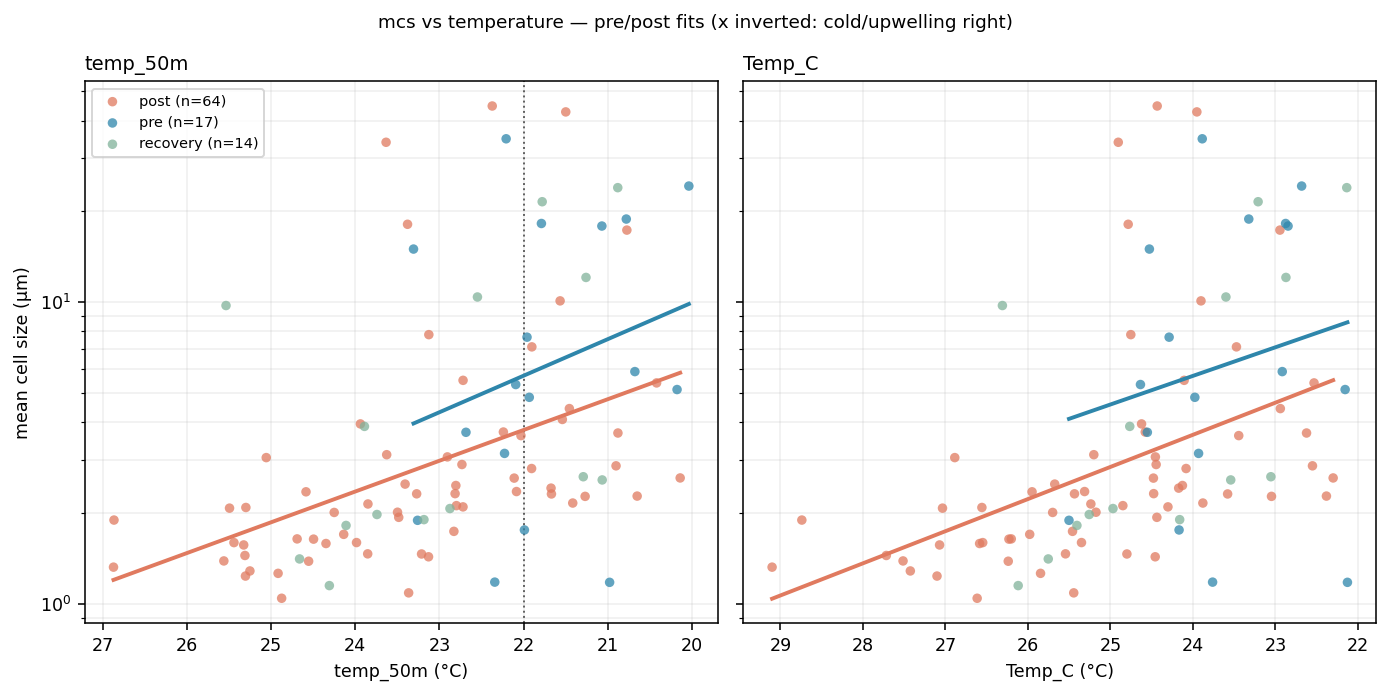

In [11]:
# ============================================================================
# Fig 4 — reconcile with Fig 3: era level-shift on temp_50m vs Temp_C (euphotic),
# pre-vs-post AND pre+rec-vs-post, + WHERE on the temp axis it lives
# (within-upwelling vs within-relaxed). Resolves "does relaxed actually separate?"
# ============================================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import mannwhitneyu
try:
    from cariaco_obs import DEFAULT_CSV_PATH as CSV
except Exception:
    CSV = "data/processed/cariaco_monthly_euphotic_dynamic.csv"

PHYTO = ["pico_mmolN","nano_mmolN","micro_mmolN"]; LOG_GEO = np.log10([0.63,6.3,63.0])
PRE_CUT, REC_CUT = pd.Timestamp("2005-01-01"), pd.Timestamp("2014-01-01")
ERA_C = {"pre":"#2E86AB","post":"#E07A5F","recovery":"#81B29A"}

df = pd.read_csv(CSV); df["date"] = pd.to_datetime(df["date"])
P = df[PHYTO].to_numpy(float); tot = P.sum(1)
with np.errstate(invalid="ignore", divide="ignore"):
    fr = np.where(tot[:,None]>0, P/tot[:,None], np.nan)
df["centroid"] = np.where(tot>0, np.nansum(fr*LOG_GEO,1), np.nan)
df["mcs"] = 10**df["centroid"]
df["era"] = np.where(df["date"]<PRE_CUT,"pre", np.where(df["date"]>=REC_CUT,"recovery","post"))

def ancova(tcol, group):
    d2 = df.dropna(subset=["centroid", tcol]).copy()
    if group=="pre_post":
        d2 = d2[d2.era.isin(["pre","post"])]; d2["hi"]=(d2.era=="pre").astype(int)
    else:
        d2 = d2[d2.era.isin(["pre","recovery","post"])]; d2["hi"]=(d2.era!="post").astype(int)
    m  = smf.ols(f"centroid ~ {tcol} + hi", data=d2).fit()
    mi = smf.ols(f"centroid ~ {tcol} * hi", data=d2).fit()
    return 10**m.params["hi"], m.pvalues["hi"], mi.pvalues[f"{tcol}:hi"], len(d2)

print("=== era level-shift  ANCOVA  centroid ~ temp + era  (fold = 10^coef) ===")
for tcol in ["temp_50m","Temp_C"]:
    for grp in ["pre_post","prerec_post"]:
        fold,p,pi,n = ancova(tcol, grp)
        print(f"  {tcol:9s} {grp:12s}  fold={fold:.2f}x  p_shift={p:.3f}  p_inter={pi:.3f}  n={n}")

print("\n=== where it lives: within-regime raw mcs contrast (median fold, MWU>) ===")
d2 = df.dropna(subset=["centroid","temp_50m"])
for side, mask in [("upwelling(<=22)", d2.temp_50m<=22), ("relaxed(>22)", d2.temp_50m>22)]:
    s = d2[mask]
    for grp, hi in [("pre/post", s.era=="pre"), ("prerec/post", s.era!="post")]:
        a, b = s[hi]["mcs"], s[s.era=="post"]["mcs"]
        if min(len(a),len(b))>=3:
            p = mannwhitneyu(a,b,alternative="greater").pvalue
            print(f"  {side:16s} {grp:12s} fold={a.median()/b.median():.2f}x (n={len(a)}/{len(b)}, MWU p={p:.3f})")
        else:
            print(f"  {side:16s} {grp:12s} too thin (n={len(a)}/{len(b)})")

plt.rcParams.update({"figure.dpi":140,"font.size":9})
fig, axes = plt.subplots(1,2, figsize=(10,5), sharey=True)
for ax, tcol in zip(axes, ["temp_50m","Temp_C"]):
    s_all = df.dropna(subset=["centroid", tcol])
    for era in ["post","pre","recovery"]:
        s = s_all[s_all.era==era]
        ax.scatter(s[tcol], s["mcs"], s=24, c=ERA_C[era], edgecolors="none",
                   alpha=0.75, label=f"{era} (n={len(s)})", zorder=3)
    for era in ["pre","post"]:           # Fig 3 comparison: pre vs post fits
        s = s_all[s_all.era==era]
        if len(s)>=3:
            b = np.polyfit(s[tcol], s["centroid"],1); xx=np.linspace(s[tcol].min(),s[tcol].max(),20)
            ax.plot(xx, 10**(b[0]*xx+b[1]), color=ERA_C[era], lw=2, zorder=4)
    if tcol=="temp_50m": ax.axvline(22, ls=":", c="k", lw=1, alpha=0.6)
    ax.invert_xaxis(); ax.set_yscale("log")
    ax.set_xlabel(f"{tcol} (°C)"); ax.grid(alpha=0.2, which="both"); ax.set_title(tcol, loc="left", fontsize=10)
axes[0].set_ylabel("mean cell size (µm)"); axes[0].legend(fontsize=7.5, loc="upper left")
fig.suptitle("mcs vs temperature — pre/post fits (x inverted: cold/upwelling right)", fontsize=9.5)
fig.tight_layout(); plt.show()

metric             | regime    | present med (n) | absent med (n) | MWU p
  mcs (µm)           upwelling pres=7.66 (n=15) | abs=3.28 (n=16) | p=0.101
  mcs (µm)           relaxed   pres=2.03 (n=12) | abs=2.01 (n=46) | p=0.295
  Micro fraction     upwelling pres=0.424 (n=15) | abs=0.181 (n=16) | p=0.109
  Micro fraction     relaxed   pres=0.139 (n=12) | abs=0.0866 (n=46) | p=0.097
  Nano fraction      upwelling pres=0.193 (n=15) | abs=0.255 (n=16) | p=0.093
  Nano fraction      relaxed   pres=0.217 (n=12) | abs=0.268 (n=46) | p=0.153
  Pico fraction      upwelling pres=0.339 (n=15) | abs=0.498 (n=16) | p=0.199
  Pico fraction      relaxed   pres=0.59 (n=12) | abs=0.607 (n=46) | p=0.393
  Zoo >200 (mmolN)   upwelling pres=0.0566 (n=23) | abs=0.0866 (n=28) | p=0.000
  Zoo >200 (mmolN)   relaxed   pres=0.0364 (n=31) | abs=0.0481 (n=59) | p=0.051
  PhaeoChl ratio     upwelling pres=0.816 (n=50) | abs=1.01 (n=28) | p=0.015
  PhaeoChl ratio     relaxed   pres=1.03 (n=51) | abs=1.09 (n=57) | p

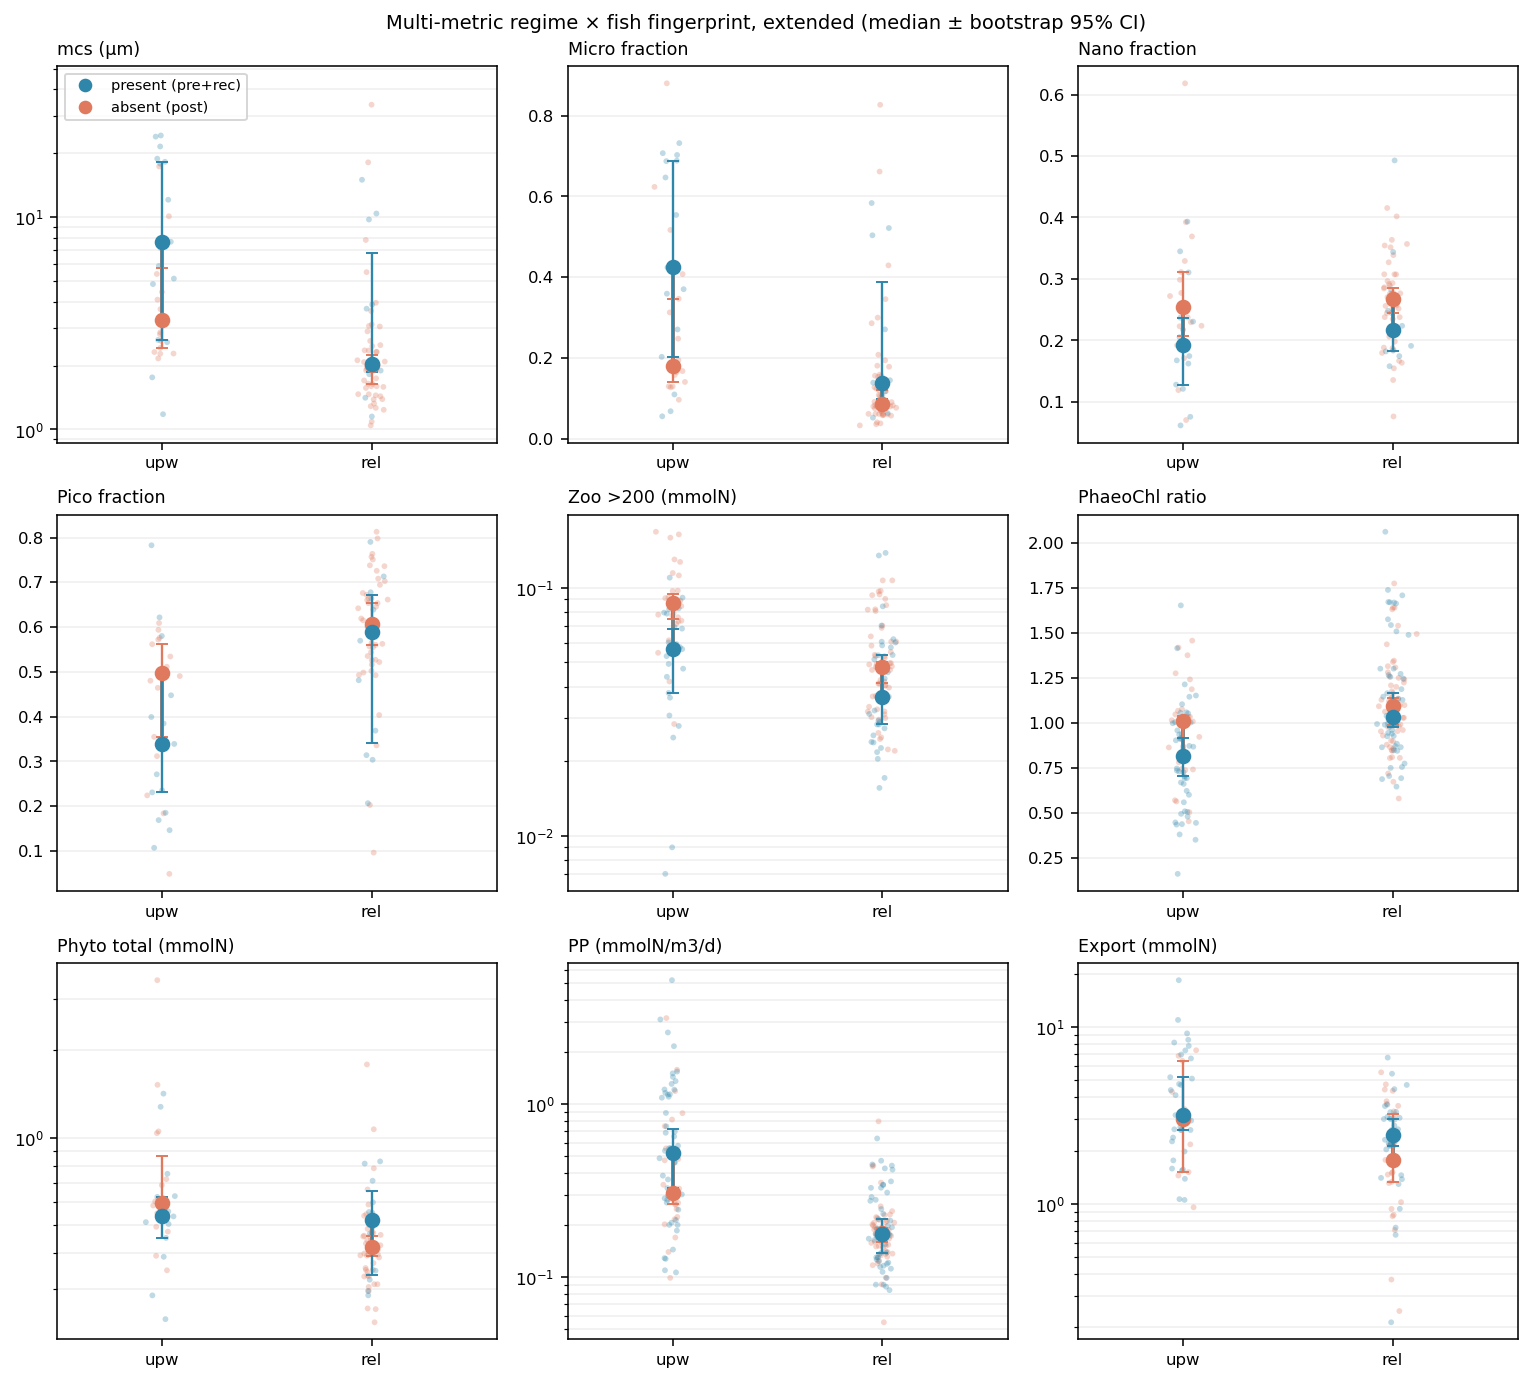

In [13]:
# ============================================================================
# Fig 4 — Step 1: multi-metric regime x fish fingerprint, EXTENDED.
# Adds phyto total biomass, PP, export to mcs + composition + zoo + PhaeoChl.
# regime_adjusted (clean), fish = pre+rec (present) vs post (absent).
# ============================================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from matplotlib.lines import Line2D
np.random.seed(0)
try:
    from cariaco_obs import DEFAULT_CSV_PATH as CSV
except Exception:
    CSV = "data/processed/cariaco_monthly_euphotic_dynamic.csv"

PHYTO = ["pico_mmolN","nano_mmolN","micro_mmolN"]; LOG_GEO = np.log10([0.63,6.3,63.0])
PRE_CUT, REC_CUT = pd.Timestamp("2005-01-01"), pd.Timestamp("2014-01-01")
COL = {"present":"#2E86AB","absent":"#E07A5F"}

df = pd.read_csv(CSV); df["date"] = pd.to_datetime(df["date"])
A = df[PHYTO].to_numpy(float); tot = A.sum(1)
with np.errstate(invalid="ignore", divide="ignore"):
    fr = np.where(tot[:,None]>0, A/tot[:,None], np.nan)
df["centroid"] = np.where(tot>0, np.nansum(fr*LOG_GEO,1), np.nan)
df["mcs"]=10**df["centroid"]; df["pico_frac"],df["nano_frac"],df["micro_frac"]=fr[:,0],fr[:,1],fr[:,2]
df["phyto_total"] = tot                                  # ΣP (mmolN), HPLC-complete months only
era = np.where(df["date"]<PRE_CUT,"pre", np.where(df["date"]>=REC_CUT,"recovery","post"))
df["fish"] = np.where(era=="post","absent","present")
df["regime"] = df["regime_adjusted"] if "regime_adjusted" in df.columns else df["upwelling"]
d = df[df["regime"].isin(["upwelling","relaxed"])].copy()

metrics = [("mcs","mcs (µm)",True),("micro_frac","Micro fraction",False),
           ("nano_frac","Nano fraction",False),("pico_frac","Pico fraction",False),
           ("zoo_gt200_mmolN","Zoo >200 (mmolN)",True),("PhaeoChl_ratio","PhaeoChl ratio",False),
           ("phyto_total","Phyto total (mmolN)",True),("PP_mmolN_m3_d","PP (mmolN/m3/d)",True),
           ("export_flux_corrected_mmolN","Export (mmolN)",True)]

def med_ci(v,n=2000):
    v=np.asarray(v,float); v=v[np.isfinite(v)]
    if len(v)<2: return (v.mean() if len(v) else np.nan),np.nan,np.nan
    bs=[np.median(np.random.choice(v,len(v),True)) for _ in range(n)]
    return np.median(v),np.percentile(bs,2.5),np.percentile(bs,97.5)

print("metric             | regime    | present med (n) | absent med (n) | MWU p")
for col,lab,_ in metrics:
    if col not in d.columns: print(f"  {lab}: column missing"); continue
    for reg in ["upwelling","relaxed"]:
        s=d[d.regime==reg]; pv=s[s.fish=="present"][col].dropna(); av=s[s.fish=="absent"][col].dropna()
        p=mannwhitneyu(pv,av).pvalue if min(len(pv),len(av))>=3 else np.nan
        print(f"  {lab:18s} {reg:9s} pres={pv.median():.3g} (n={len(pv):2d}) | "
              f"abs={av.median():.3g} (n={len(av):2d}) | p={p:.3f}")

plt.rcParams.update({"figure.dpi":140,"font.size":8.5})
fig, axes = plt.subplots(3,3, figsize=(11,10))
for ax,(col,lab,logy) in zip(axes.flat, metrics):
    if col not in d.columns: ax.set_title(f"[missing] {lab}"); ax.axis("off"); continue
    for i,reg in enumerate(["upwelling","relaxed"]):
        x=i+1; st={}
        for fi in ["absent","present"]:
            v=d[(d.regime==reg)&(d.fish==fi)][col].dropna().values; st[fi]=med_ci(v)
            ax.scatter(np.random.normal(x,0.03,len(v)), v, s=9, c=COL[fi], edgecolors="none", alpha=0.30, zorder=2)
        ax.plot([x,x],[st['absent'][0],st['present'][0]], color="0.5", lw=2, zorder=3)
        for fi in ["absent","present"]:
            m,lo,hi=st[fi]
            ax.errorbar(x,m,yerr=([[m-lo],[hi-m]] if np.isfinite(lo) else None), fmt='o',
                        ms=7, color=COL[fi], ecolor=COL[fi], elinewidth=1.2, capsize=3, zorder=4)
    if logy: ax.set_yscale("log")
    ax.set_xticks([1,2]); ax.set_xticklabels(["upw","rel"]); ax.set_xlim(0.5,2.6)
    ax.set_title(lab, loc="left", fontsize=9); ax.grid(alpha=0.2, axis="y", which="both")
axes[0,0].legend(handles=[Line2D([],[],marker='o',ls='',color=COL['present'],label='present (pre+rec)'),
                          Line2D([],[],marker='o',ls='',color=COL['absent'],label='absent (post)')],
                 fontsize=7.5, loc="upper left")
fig.suptitle("Multi-metric regime × fish fingerprint, extended (median ± bootstrap 95% CI)", fontsize=10)
fig.tight_layout(); plt.show()